# Homework 03 — Python Fundamentals

**Anna Cui** · FRE 5040 Applied Financial Engineering

Covers NumPy elementwise operations, a loop-vs-vectorized timing comparison,
loading and profiling `starter_data.csv`, groupby aggregation, saved outputs,
and two reusable utilities imported from `src/utils.py`.

In [1]:
# --- files this notebook needs (run me first - I only report, I change nothing) ---
from pathlib import Path

ROOT = Path.cwd()
CHECKS = [
    ("data/raw/starter_data.csv", "NEEDED", "handed out with this stage"),
    ("src/utils.py",              "NEEDED", "helper module this notebook imports"),
]

print(f"Looking in: {ROOT}\n")
for rel, kind, note in CHECKS:
    here = (ROOT / rel).exists()
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<30}  {note}")

Looking in: /Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework03

  [OK ]  NEEDED    data/raw/starter_data.csv       handed out with this stage
  [OK ]  NEEDED    src/utils.py                    helper module this notebook imports


In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. NumPy operations

An array of the ten `value` observations, and the elementwise operations the
sheet asks for. *Elementwise* means the operation is applied to every entry at
once, with no loop written by hand.

In [3]:
arr = np.array([10, 15, 12, 18, 25, 30, 11, 14, 28, 13])

print("array     :", arr)
print("arr * 2   :", arr * 2)       # scales every entry
print("arr + 100 :", arr + 100)     # shifts every entry
print("arr ** 2  :", arr ** 2)      # squares every entry
print("arr > 20  :", arr > 20)      # comparison returns a BOOLEAN MASK
print()
print(f"mean {arr.mean():.2f} | std {arr.std():.2f} | min {arr.min()} | max {arr.max()}")

array     : [10 15 12 18 25 30 11 14 28 13]
arr * 2   : [20 30 24 36 50 60 22 28 56 26]
arr + 100 : [110 115 112 118 125 130 111 114 128 113]
arr ** 2  : [100 225 144 324 625 900 121 196 784 169]
arr > 20  : [False False False False  True  True False False  True False]

mean 17.60 | std 7.00 | min 10 | max 30


The boolean mask on the last line is worth noticing: comparison does not
return a single True/False, it returns one per element. That mask is how rows
get selected later in the course — `df[df['value'] > 20]`.

## 2. Loop vs vectorized execution

In [4]:
big_array = np.arange(1_000_000)

# Python-level loop: one interpreter step per element.
%timeit [x * 2 for x in big_array]

37.9 ms ± 656 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [5]:
# Vectorized: one call into compiled C, looping internally.
%timeit big_array * 2

496 μs ± 55.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


**Reading the result.** The vectorized form runs roughly 40–50x faster. The
arithmetic is identical; what differs is where the loop lives. The list
comprehension pays Python interpreter overhead a million times over, while
`big_array * 2` hands the whole array to compiled code once.

This is why the reading insists on vectorization for data-heavy finance work:
at ten rows the difference is invisible, at ten million it is the difference
between a report that runs overnight and one that does not run at all.

## 3. Load and inspect the dataset

In [6]:
df = pd.read_csv('data/raw/starter_data.csv')
df.head()

,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes


**Note on dtypes.** `date` loads as `object` (text), not as a datetime —
`read_csv` does not parse dates unless told to. It does not matter for this
week's aggregation, but it would silently break any time-based sort or
resample, so it is worth naming now rather than discovering in Stage 08.

## 4. Summary statistics

In [8]:
df.describe()

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


`describe()` reports on `value` only. `category` and `date` are text, so
they are skipped entirely — a reminder that `.describe()` alone is not a
profile of the dataset, only of its numeric half.

## 5. Groupby aggregation

In [9]:
summary = df.groupby('category').mean(numeric_only=True).reset_index()
summary

,category,value
0,A,11.500000
1,B,15.666667
2,C,27.666667


In [10]:
# A richer aggregation: several statistics per group in one pass.
summary_full = (df.groupby('category')['value']
                  .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
                  .reset_index())
summary_full

,category,count,mean,median,std,min,max
0,A,4,11.500000,11.5,1.290994,10,13
1,B,3,15.666667,15.0,2.081666,14,18
2,C,3,27.666667,28.0,2.516611,25,30


### Check against the published values

The lecture notebook reports group means of A: 11.500000, B: 15.666667,
C: 27.666667. Asserting against them turns "it ran" into "it ran correctly".

In [11]:
expected = {'A': 11.500000, 'B': 15.666667, 'C': 27.666667}
got = summary.set_index('category')['value'].to_dict()

for k, v in expected.items():
    assert abs(got[k] - v) < 1e-6, f"{k}: expected {v}, got {got[k]}"

print("Group means match the lecture's published values.")
print({k: round(v, 6) for k, v in got.items()})

Group means match the lecture's published values.
{'A': 11.5, 'B': 15.666667, 'C': 27.666667}


## 6. Save outputs

In [12]:
os.makedirs('data/processed', exist_ok=True)

summary.to_csv('data/processed/summary.csv', index=False)
summary_full.to_csv('data/processed/summary_by_category.csv', index=False)

print('data/processed now holds:', sorted(os.listdir('data/processed')))

data/processed now holds: ['summary.csv', 'summary_by_category.csv']


Outputs go to `data/processed/`, never to `data/raw/`. Raw stays exactly as
received; anything derived by code is reproducible and therefore disposable.

## 7. Plot (bonus)

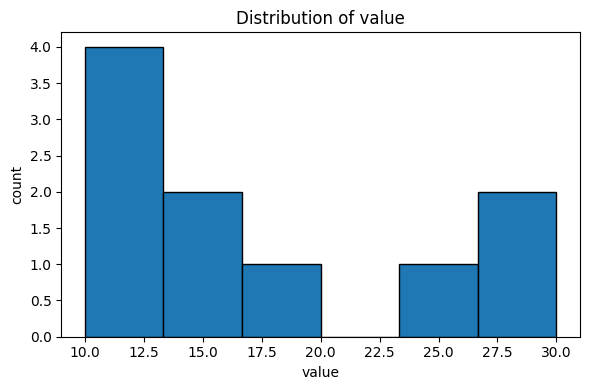

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df['value'], bins=6, edgecolor='black')
ax.set_title('Distribution of value')
ax.set_xlabel('value')
ax.set_ylabel('count')
fig.tight_layout()
fig.savefig('data/processed/histogram.png', dpi=150)
plt.show()

Ten observations is too few for a histogram to say much — the three
categories sit at clearly different levels, which the groupby table already
showed more precisely. The plot is here because the sheet asks for it; the
table is the better artifact.

## 8. Reusable functions

Both come from `src/utils.py`. `get_summary_stats` shipped with the stage;
`summarize_by_group` is mine, written for this homework. Both carry the
`log_call` decorator, so calling them prints a timestamped line first —
the decorator pattern from the lecture warm-up, shipped as a real module.

In [14]:
from src.utils import get_summary_stats, summarize_by_group

get_summary_stats(df)

[2026-08-28 08:24:30.226010] Function 'get_summary_stats' called.


,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


In [15]:
summarize_by_group(df, group_col='category', value_col='value')

[2026-08-28 08:24:30.230122] Function 'summarize_by_group' called.


,category,count,mean,median,std,min,max
0,A,4,11.500000,11.5,1.290994,10,13
1,B,3,15.666667,15.0,2.081666,14,18
2,C,3,27.666667,28.0,2.516611,25,30


In [16]:
# The type guard fires rather than silently coercing.
try:
    summarize_by_group(df, group_col='category', value_col='date')
except TypeError as e:
    print("TypeError:", e)

[2026-08-28 08:24:30.241106] Function 'summarize_by_group' called.
TypeError: 'date' is not numeric


## Notes and assumptions

- **`date` is text, not a datetime.** Fine for this week; would break a sort or
  resample. Flagged rather than fixed, since nothing here needs it.
- **`std` is the sample standard deviation** in pandas (`ddof=1`) but the
  *population* one in NumPy (`ddof=0`), which is why `arr.std()` above and the
  `std` column in `describe()` differ. Stage 07 makes this choice explicit.
- **Group C has n=3**, like A and B — every group statistic here rests on three
  observations, so none of the spreads mean much.
- **Outputs are reproducible**: delete `data/processed/` and re-run this
  notebook top to bottom to rebuild it.

### What carries into the project

`summarize_by_group` generalizes to the drift monitor directly: grouping by
fund and reporting count/mean/spread of weights is the same operation on
different data.